<div class="alert alert-block alert-info">
<center><strong> Predict if a family is living in Urban/Rural area based on building type, roof type, and type of walls. </strong></center>
</div>

<hr/>
<center> A major course output (MCO) in completing 20% of final grade in Advanced Intelligent Systems (STINTSY) </center> 

Term 2 A.Y. 2025-2026
<br/>
**Group #2 CSINTSY Survivors (Section S18)**

| Member Name | Contributions |
| ----- | -----  |
| Chavez, Allen Visagar | text  |
| Llanes, Andre Gabriel De Ocampo  | text  |
| Rojo, Von Matthew De Guzman *(leader)* | text |
| Tan, Jeremy James Teves | text |

Professor: Antioquia, Arren Matthew Capuchino
<hr/>

In [183]:
## Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np # for importing datasets
import math
import pandas as pd

%load_ext autoreload
%autoreload 2
from MCO_functions import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# **[1]** Data Preparation
**Dataset Name:** Family Income and Expenditure Survey 2012 Vol 1
<br/>
**Accessed from:** [click this link](https://psada.psa.gov.ph/catalog/38/data-dictionary/F2?file_name=fies2012_v1)

In [184]:
csv_path = 'feis_dataset/FIES PUF 2012 Vol.1.CSV'
csvdict_path = 'feis_dataset/fies_2012_v1_metadata(dictionary)'
fies_original_df = pd.read_csv(csv_path)

fies_original_df

,W_REGN,W_OID,W_SHSN,W_HCN,URB,RSTR,PSU,BWEIGHT,RFACT,FSIZE,...,PC_QTY,OVEN_QTY,MOTOR_BANCA_QTY,MOTORCYCLE_QTY,POP_ADJ,PCINC,NATPC,NATDC,REGDC,REGPC
0,14,101001000,2,25,2,21100,415052,138.25,200.6576,3.0,...,01,01,,,0.946172,108417.00,9,8,8,9
1,14,101001000,3,43,2,21100,415052,138.25,200.6576,12.5,...,,01,,01,0.946172,30631.60,5,9,9,4
2,14,101001000,4,62,2,21100,415052,138.25,200.6576,2.0,...,,01,,,0.946172,86992.50,9,6,6,8
3,14,101001000,5,79,2,21100,415052,138.25,200.6576,4.0,...,,01,,,0.946172,43325.75,6,6,6,6
4,14,101001000,10,165,2,21100,415052,138.25,200.6576,5.0,...,,,,01,0.946172,37481.80,6,6,6,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40166,12,9804029001,18,568,1,22000,114062,271.25,963.2264,5.0,...,00,00,00,00,0.902863,30101.60,5,5,7,7
40167,12,9804035000,1,25,2,22000,414067,271.25,588.6253,9.0,...,00,01,00,00,0.902863,14368.89,1,5,7,3
40168,12,9804035000,2,51,2,22000,414067,271.25,588.6253,6.0,...,00,00,00,00,0.902863,19137.33,3,4,6,4
40169,12,9804035000,3,75,2,22000,414067,271.25,588.6253,5.0,...,00,01,00,00,0.902863,30985.00,5,6,7,7


# **[2]** Exploratory Data Analysis (EDA)
This phase allows exploration of datasets and check any anomalies present.
1. Basic Dataset Information
2. Urban and Rural Comparative Statistics

# **[2.1]** Basic Dataset Information
- column statistics
- number of null values
- number of duplicated entries

In [185]:
# summary for all columns
description = fies_original_df.describe().T
print(description.to_string())

                        count          mean           std           min           25%           50%           75%           max
W_REGN                40171.0  1.301989e+01  1.199555e+01  1.000000e+00  6.000000e+00  1.000000e+01  1.400000e+01  4.200000e+01
W_OID                 40171.0  4.210536e+09  2.285729e+09  1.010010e+08  2.239012e+09  4.112005e+09  6.210006e+09  9.804035e+09
W_SHSN                40171.0  9.633666e+00  6.198442e+00  1.000000e+00  4.000000e+00  9.000000e+00  1.400000e+01  3.000000e+01
W_HCN                 40171.0  1.563602e+03  2.977364e+03  1.000000e+00  9.500000e+01  2.040000e+02  3.930000e+02  8.026000e+03
URB                   40171.0  1.617311e+00  4.860494e-01  1.000000e+00  1.000000e+00  2.000000e+00  2.000000e+00  2.000000e+00
RSTR                  40171.0  2.154728e+04  3.520981e+03  2.475000e+03  2.110000e+04  2.210000e+04  2.320000e+04  2.900000e+04
PSU                   40171.0  2.581237e+05  1.121433e+05  1.000100e+05  1.163840e+05  2.162120e+05  3.1

In [186]:
# check if there is any null values or whitespaces
ws_or_na_df = fies_original_df.replace(r'^\s*$', pd.NA, regex=True)
ws_or_na_ctr = ws_or_na_df.isna().sum()
print("Whitespaces or null value counts: ")
print(ws_or_na_ctr.to_string())

Whitespaces or null value counts: 
W_REGN                      0
W_OID                       0
W_SHSN                      0
W_HCN                       0
URB                         0
RSTR                        0
PSU                         0
BWEIGHT                     0
RFACT                       0
FSIZE                       0
AGRI_SAL                    0
NONAGRI_SAL                 0
WAGES                       0
NETSHARE                    0
CASH_ABROAD                 0
CASH_DOMESTIC               0
RENTALS_REC                 0
INTEREST                    0
PENSION                     0
DIVIDENDS                   0
OTHER_SOURCE                0
NET_RECEIPT                 0
REGFT                       0
NET_CFG                     0
NET_LPR                     0
NET_FISH                    0
NET_FOR                     0
NET_RET                     0
NET_MFG                     0
NET_COM                     0
NET_TRANS                   0
NET_MIN                     0
NET_C

In [187]:
# check if there are any duplicates
dupes = fies_original_df.duplicated().sum()

if (dupes <= 0):
  print('There are no duplicates')
else:
  print('There are', dupes, 'duplicates')

There are no duplicates


# **[2.2]** Urban and Rural Comparative Statistics
- income and expenditure distribution
- regional distribution
- household composition

In [188]:
columns = ws_or_na_df.columns
T_columns = [col for col in columns if col.startswith("T_")] # categories
NET_columns = [col for col in columns if col.startswith("NET_")] # categories
NET_columns.extend(["REGFT","EAINC","TOINC"])

rural_df =  ws_or_na_df[ws_or_na_df["URB"] == 2]
urban_df = ws_or_na_df[ws_or_na_df["URB"] == 1]

rural_T_df = rural_df[T_columns]
urban_T_df = urban_df[T_columns]

rural_T_mean_sr = rural_T_df.mean()
urban_T_mean_sr = urban_T_df.mean()


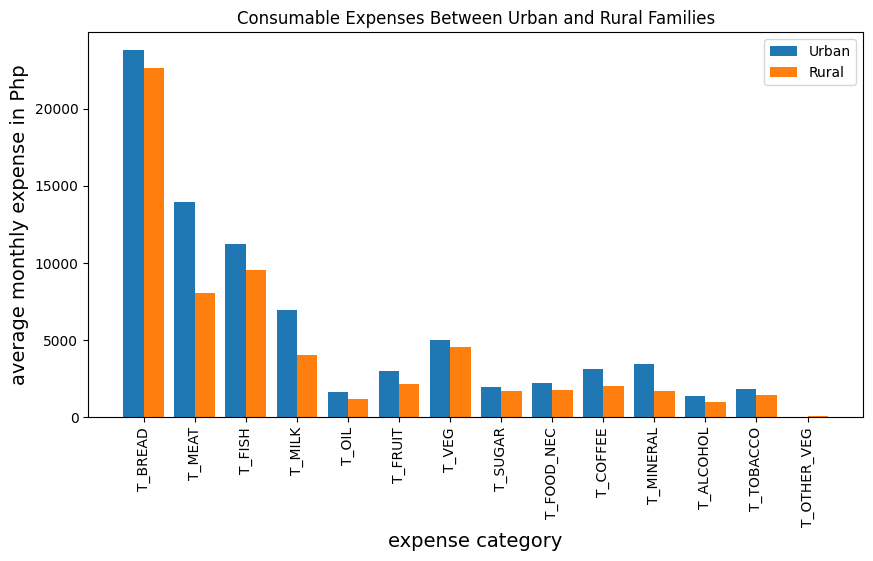

In [189]:
# create x-axis values depending on the number of features and width of bar
consumables_columns = ["T_BREAD","T_MEAT","T_FISH","T_MILK","T_OIL","T_FRUIT","T_VEG","T_SUGAR","T_FOOD_NEC","T_COFFEE","T_MINERAL","T_ALCOHOL","T_TOBACCO","T_OTHER_VEG"]
rural_columns = rural_T_mean_sr[consumables_columns]
urban_columns = urban_T_mean_sr[consumables_columns]

x_axis = np.arange(len(consumables_columns))
w = 0.4

# increase figure size
plt.figure(figsize=(10,5))

# bar profile
plt.bar(x_axis - 0.2, urban_columns, width=w, label="Urban")
plt.bar(x_axis + 0.2, rural_columns, width=w, label="Rural")

# set tick labels and their location
plt.xticks(x_axis, consumables_columns, rotation=90)

plt.xlabel("expense category", fontsize=14)
plt.ylabel("average monthly expense in Php", fontsize=14)
plt.title("Consumable Expenses Between Urban and Rural Families")

# add legend
plt.legend()
plt.show()

# credits: https://hyperskill.org/learn/step/16796#grouped-bar-plot


# **[3]** Data Preprocessing
sample text here

# **[4]** Model Selection Training


## Classical machine learning model #1

## Classical machine learning model #2

## Classical machine learning model #3

## Neural Network model #1


## Neural Network model #2

# **[5]** Error Analysis and Model Tuning
sample text here

# **[6]** Model Evaluation
sample text here

<hr/>

# AI Declaration
Chavez, Allen Visagar
- sample text

Llanes, Andre Gabriel De Ocampo
- sample text

Rojo, Von Matthew De Guzman *(leader)*
- Uses Google-search that has AI features in synthesizing different sources relevant to questions I asked.
- Uses Google Gemini to ask ways on how to import CSV dataset and scaffolding ideas for EDA

Tan, Jeremy James Teves
- sample text